In [3]:
import torch
import torch.nn as nn
import kagglehub
import os
from pathlib import Path
import shutil
from torchvision import datasets
from torch.utils.data import Subset, DataLoader, Dataset, random_split
import random
from torchvision.transforms import v2
import torch.optim as optim
from typing import Tuple, Dict, List
from tqdm import tqdm
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import copy
import torch.optim.lr_scheduler as lr_scheduler



device = "cuda" if torch.cuda.is_available() else "cpu"

def process(device: torch.device,
            data_root: str = "data/",
            dataset_name: str = "miljan/stanford-dogs-dataset-traintest",
            num_classes: int = 5,
            batch_size: int = 32,
            seed: int = 42,
            num_workers: int = 2,
            layer_1: int =32,
            layer_2: int =64,
            layer_3: int =128,
            learning_rate: float = 0.0005,
            loss_fn: torch.nn = nn.CrossEntropyLoss(),
            epochs: int = 10,
            early_stopping_patience: int = 15,
            scheduling_patience: int = 3,
            weight_decay: float = 0.0001,
            step_size: int = 8,
            factor: float = 0.5,
            val_split: float = 0.1
            ):
    
    class RemapSubset(Dataset):
        """Wraps a Subset and remaps labels to contiguous [0..num_classes-1]."""
        def __init__(self, subset, selected_indices):
            self.subset = subset
            self.label_map = {old: new for new, old in enumerate(selected_indices)}
    
        def __len__(self):
            return len(self.subset)
    
        def __getitem__(self, idx):
            x, y = self.subset[idx]
            return x, self.label_map[y]

    def load_kaggle(data_root: str = "data/",
                    dataset_name: str = "miljan/stanford-dogs-dataset-traintest",
                    num_classes: int = None,
                    batch_size: int = 32,
                    seed: int = 42,
                    num_workers: int = 2):
        """
        Download, prepare and optionally subset the Stanford Dogs dataset.
        Labels are remapped to contiguous indices when subsetting.
    
        Args:
            data_root (str): Root folder to store data.
            dataset_name (str): Kaggle dataset identifier.
            num_classes (int): If provided, randomly subset to this many classes.
            batch_size (int): Batch size for dataloaders.
            seed (int): Random seed for reproducibility.
    
        Returns:
            train_dataloader, test_dataloader, class_names
        """
        data_path = Path(data_root)
        image_path = data_path / "dog_breeds"
    
        # Download if not already present
        if not image_path.is_dir():
            print(f"{image_path} directory doesn't exist ... downloading dataset")
            image_path.mkdir(parents=True, exist_ok=True)
            original_path = kagglehub.dataset_download(dataset_name)
            shutil.copytree(original_path, image_path, dirs_exist_ok=True)
        else:
            print(f"{image_path} directory exists already ... skipping download")
    
        # Define train/test dirs
        train_dir = image_path / "cropped/cropped/train"
        test_dir = image_path / "cropped/cropped/test"
    
        # Define transforms
        transforms = v2.Compose([
            v2.ToImage(),
            v2.Resize(size=(224, 224), antialias=True),
            v2.ToDtype(torch.float32, scale=True),  # scales to [0,1]
        ])
        train_transforms = v2.Compose([
            v2.ToImage(),
            v2.Resize((224,224), antialias=True),
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(10),
            v2.ColorJitter(brightness=0.2, contrast=0.2),
            v2.ToDtype(torch.float32, scale=True),
        ])

    
        # Load datasets
        full_train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
        test_data = datasets.ImageFolder(root=test_dir, transform=transforms)
    
        if num_classes is not None:
            random.seed(seed)
            selected_classes = random.sample(full_train_data.classes, num_classes)
            class_to_idx = full_train_data.class_to_idx
            selected_indices = [class_to_idx[c] for c in selected_classes]
    
            train_subset_indices = [i for i, (_, label) in enumerate(full_train_data.samples) if label in selected_indices]
            test_subset_indices = [i for i, (_, label) in enumerate(test_data.samples) if label in selected_indices]
    
            full_train_data = RemapSubset(Subset(full_train_data, train_subset_indices), selected_indices)
            test_data = RemapSubset(Subset(test_data, test_subset_indices), selected_indices)
    
            class_names = [c.split("-", 1)[1] for c in selected_classes]
            print(f"Selected Classes: {class_names}")
        else:
            class_names = [c.split("-", 1)[1] for c in full_train_data.classes]
    
        # Split train into train + validation
        val_size = int(len(full_train_data) * val_split)
        train_size = len(full_train_data) - val_size
        train_data, val_data = random_split(full_train_data, [train_size, val_size],
                                            generator=torch.Generator().manual_seed(seed))



        # Create dataloaders
        train_dataloader = DataLoader(train_data,
                                  batch_size=batch_size,
                                  shuffle=True,
                                  num_workers=0,   
                                  pin_memory=False)
    
        test_dataloader = DataLoader(test_data,
                                     batch_size=batch_size,
                                     shuffle=False,
                                     num_workers=0,
                                     pin_memory=False)
        val_dataloader = DataLoader(val_data,
                                     batch_size=batch_size,
                                     shuffle=False,
                                     num_workers=0,
                                     pin_memory=False)
    
        return train_dataloader, test_dataloader, val_dataloader, class_names

    train_dataloader, test_dataloader, val_dataloader, class_names = load_kaggle(num_classes=num_classes)

    class DogBreedClassifier(nn.Module):
        def __init__(self,
                     in_size: int,
                     layer_1: int,
                     layer_2: int,
                     layer_3: int,
                     out_size: int):
            super().__init__()
            
            # Convolutional blocks with BatchNorm + padding
            self.conv_block_1 = nn.Sequential(
                nn.Conv2d(in_channels=in_size, out_channels=layer_1, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_1),
                nn.ReLU(),
                nn.Conv2d(in_channels=layer_1, out_channels=layer_1, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            self.conv_block_2 = nn.Sequential(
                nn.Conv2d(in_channels=layer_1, out_channels=layer_2, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_2),
                nn.ReLU(),
                nn.Conv2d(in_channels=layer_2, out_channels=layer_2, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_2),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            self.conv_block_3 = nn.Sequential(
                nn.Conv2d(in_channels=layer_2, out_channels=layer_3, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_3),
                nn.ReLU(),
                nn.Conv2d(in_channels=layer_3, out_channels=layer_3, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(layer_3),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            
            # Global Average Pooling instead of flatten
            self.gap = nn.AdaptiveAvgPool2d((1,1))
            
            # Classifier with hidden dense layer
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Dropout(p=0.5),
                nn.Linear(layer_3, 2*layer_3),
                nn.ReLU(),
                nn.Dropout(p=0.5),
                nn.Linear(2*layer_3, out_size)
            )
            
        def forward(self, x):
            x = self.conv_block_1(x)
            x = self.conv_block_2(x)
            x = self.conv_block_3(x)
            x = self.gap(x)
            return self.classifier(x)

    model = DogBreedClassifier(in_size=3,
                               layer_1=layer_1,
                               layer_2=layer_2,
                               layer_3=layer_3,
                               out_size = len(class_names))
    
    optimizer = optim.Adam(params=model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=factor, patience=scheduling_patience)
    
    def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device) -> Tuple[float, float]:
        model.to(device)
        model.train()
        train_loss, train_acc = 0,0
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device) 
            logit = model(X)
            loss = loss_fn(logit, y)
            train_loss += loss.item()
            pred = torch.softmax(logit, dim=1).argmax(dim=1)
            train_acc += (pred==y).sum().item()/len(logit)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss /= len(dataloader)
        train_acc /= len(dataloader)
        return train_loss, train_acc

    def eval_step(model,
                  dataloader,
                  loss_fn,
                  device) -> Tuple[float, float]:
        """
        Evaluate the model on a given dataloader (validation or test).
        Returns average loss and accuracy.
        """
        model.to(device)
        model.eval()
        total_loss, total_acc = 0.0, 0.0
    
        with torch.inference_mode():
            for X, y in dataloader:
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                loss = loss_fn(logits, y)
                total_loss += loss.item()
    
                preds = torch.softmax(logits, dim=1).argmax(dim=1)
                total_acc += (preds == y).sum().item() / len(y)
    
        avg_loss = total_loss / len(dataloader)
        avg_acc = total_acc / len(dataloader)
        return avg_loss, avg_acc


    def plot_results(results):
        epochs = range(1, len(results["train_loss"]) + 1)
        plt.figure(figsize=(10,4))
    
        # Loss curves
        plt.subplot(1,2,1)
        plt.plot(epochs, results["train_loss"], label="Train Loss")
        plt.plot(epochs, results["val_loss"], label="Val Loss")
        plt.legend(); plt.title("Loss")
    
        # Accuracy curves
        plt.subplot(1,2,2)
        plt.plot(epochs, results["train_acc"], label="Train Acc")
        plt.plot(epochs, results["val_acc"], label="Val Acc")
        plt.legend(); plt.title("Accuracy")
    
        plt.show()
    
        # Print final test metrics
        if len(results["test_loss"]) > 0:
            print(f"Final Test Loss: {results['test_loss'][-1]:.4f}, "
                  f"Test Acc: {results['test_acc'][-1]:.2f}%")




    class EarlyStopping:
        def __init__(self, patience=early_stopping_patience, min_delta=0.0):
            """
            Args:
                patience (int): How many epochs to wait after last improvement.
                min_delta (float): Minimum change to qualify as improvement.
            """
            self.patience = patience
            self.min_delta = min_delta
            self.best_loss = None
            self.counter = 0
            self.should_stop = False
    
        def step(self, val_loss):
            if self.best_loss is None:
                self.best_loss = val_loss
                return
    
            if val_loss < self.best_loss - self.min_delta:
                self.best_loss = val_loss
                self.counter = 0
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    self.should_stop = True

    def train(model = model,
          train_dataloader = train_dataloader,
          test_dataloader = test_dataloader,
          loss_fn = loss_fn,
          optimizer = optimizer,
          scheduler = scheduler,
          epochs = epochs,
          device = device,
          early_stopping_patience = early_stopping_patience) -> Dict[str, List[float]]:
        """
        Trains and tests a Convolutional Neural Network.
        Passes a target PyTorch models through train_step() and test_step()
        functions for a number of epochs, training and testing the model
        in the same epoch loop.
        
        Calculates, prints and stores evaluation metrics throughout.
    
        Args:
        model: A PyTorch model to be trained and tested.
        train_dataloader: A DataLoader instance for the model to be trained on.
        test_dataloader: A DataLoader instance for the model to be tested on.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        loss_fn: A PyTorch loss function to calculate loss on both datasets.
        epochs: An integer indicating how many epochs to train for.
        device: A target device to compute on (e.g. "cuda" or "cpu").
        scheduler ...
        early_stopping_patience ...
    
        Returns:
        A dictionary of training and testing loss as well as training and
        testing accuracy metrics. Each metric has a value in a list for
        each epoch.
        model ...
        In the form: {train_loss: [...],
                      train_acc: [...],
                      test_loss: [...],
                      test_acc: [...]}
        """
        start_time = timer()
        # Create empty results dictionary
        results = {"train_loss": [],
                   "train_acc": [],
                   "val_loss": [],
                   "val_acc": [],
                   "test_loss": [],
                   "test_acc": []}
        early_stopping = EarlyStopping(patience=early_stopping_patience)
        best_model_wts = copy.deepcopy(model.state_dict())


        
        for epoch in tqdm(range(epochs), desc="Epochs"):
            # Training step
            train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
    
            # Validation step
            val_loss, val_acc = eval_step(model, val_dataloader, loss_fn, device)
    
            # Scheduler reacts to validation loss
            scheduler.step(val_loss)
    
            # Early stopping check
            if early_stopping.best_loss is None or val_loss < early_stopping.best_loss - early_stopping.min_delta:
                best_model_wts = copy.deepcopy(model.state_dict())
            early_stopping.step(val_loss)
    
            if early_stopping.should_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                model.load_state_dict(best_model_wts)
                break
    
            # Print progress
            print_train_acc = train_acc * 100
            print_val_acc = val_acc * 100
            if epoch == 0 or (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {print_train_acc:.2f}% "
                      f"| val_loss: {val_loss:.4f} | val_acc: {print_val_acc:.2f}% "
                      f"| LR: {optimizer.param_groups[0]['lr']:.6f}")
    
            # Save results
            results["train_loss"].append(train_loss)
            results["train_acc"].append(print_train_acc)
            results["val_loss"].append(val_loss)
            results["val_acc"].append(print_val_acc)
    
        # Final test evaluation
        test_loss, test_acc = eval_step(model, test_dataloader, loss_fn, device)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc * 100)
    
        end_time = timer()
        print(f"Training finished in {end_time-start_time:.2f} seconds")
        print(f"Final test loss: {test_loss:.4f}, test acc: {test_acc*100:.2f}%")
    
        plot_results(results)
        return model, results
  
    model, results = train()
    return model, results
    

data\dog_breeds directory exists already ... skipping download
Selected Classes: ['Border_collie', 'black-and-tan_coonhound', 'Pekinese', 'French_bulldog', 'Norwich_terrier']


Epochs:   2%|█▍                                                                      | 1/50 [02:10<1:46:22, 130.25s/it]

Epoch 1 | train_loss: 1.5832 | train_acc: 28.33% | val_loss: 1.6653 | val_acc: 16.15% | LR: 0.000500


Epochs:  20%|██████████████▏                                                        | 10/50 [21:44<1:26:48, 130.21s/it]

Epoch 10 | train_loss: 1.2440 | train_acc: 43.54% | val_loss: 1.3614 | val_acc: 25.52% | LR: 0.000500


...

Epochs:  80%|████████████████████████████████████████████████████████▊              | 40/50 [1:27:00<21:56, 131.68s/it]

Epoch 40 | train_loss: 0.9909 | train_acc: 58.75% | val_loss: 1.0481 | val_acc: 52.26% | LR: 0.000008


Epochs:  88%|██████████████████████████████████████████████████████████████▍        | 44/50 [1:37:31<13:17, 133.00s/it]

Early stopping triggered at epoch 45


Training finished in 5855.34 seconds
Final test loss: 1.0089, test acc: 59.42%


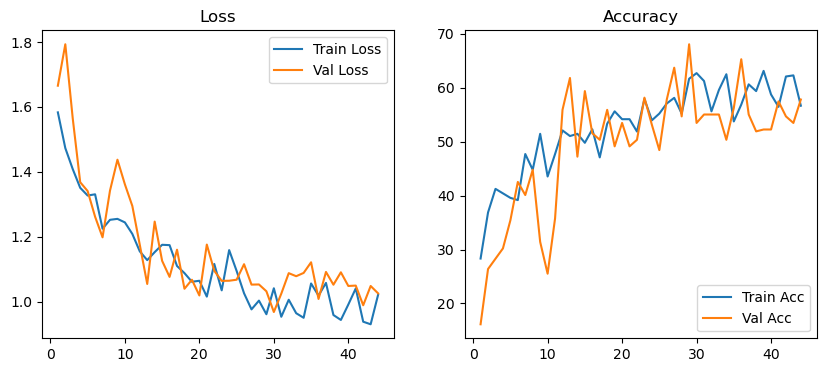

Final Test Loss: 1.0089, Test Acc: 59.42%


In [4]:
model, model_results = process(device="cuda", epochs=50)

In [6]:
import torch
from pathlib import Path

# Create a models directory if it doesn't exist
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the entire model (architecture + weights)
torch.save(model.state_dict(), models_dir / "dog_breed_classifier.pth")

In [30]:
%cd C:\Users\harri\Documents\coding\projects\pytorch
!dir
!git status

C:\Users\harri\Documents\coding\projects\pytorch
 Volume in drive C has no label.
 Volume Serial Number is 8E39-F6C3

 Directory of C:\Users\harri\Documents\coding\projects\pytorch

23/11/2025  08:43 PM    <DIR>          .
23/11/2025  09:41 AM    <DIR>          ..
23/11/2025  08:35 PM    <DIR>          .ipynb_checkpoints
23/11/2025  08:36 PM    <DIR>          .virtual_documents
23/11/2025  09:41 AM    <DIR>          anaconda_projects
23/11/2025  10:29 AM    <DIR>          data
23/11/2025  02:01 PM           683,627 dog_breeds.ipynb
23/11/2025  03:44 PM           133,244 dog_breeds2.ipynb
23/11/2025  08:43 PM           104,521 dog_breed_classifier_original.ipynb
23/11/2025  08:09 PM    <DIR>          models
23/11/2025  04:10 PM           130,587 modular.ipynb
23/11/2025  08:08 PM           100,496 mymodel2.ipynb
23/11/2025  05:33 PM           258,454 my_model.ipynb
23/11/2025  05:15 PM            87,430 new.ipynb
23/11/2025  08:26 PM           152,646 resnet.ipynb
23/11/2025  08:42 PM  

fatal: not a git repository (or any of the parent directories): .git


In [31]:
%cd C:\Users\harri\Documents

C:\Users\harri\Documents


In [32]:
!git clone https://github.com/HarrisonOC-Creator/Projects.git
%cd Projects

C:\Users\harri\Documents\Projects


Cloning into 'Projects'...


In [33]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
import shutil
from pathlib import Path

# Destination inside your repo
dest = Path("deep_learning/computer_vision/classification/dog_breed_classifier")
dest.mkdir(parents=True, exist_ok=True)

# Source files
nb_src = Path(r"C:\Users\harri\Documents\coding\projects\pytorch\dog_breed_classifier_original.ipynb")
model_src = Path(r"C:\Users\harri\Documents\coding\projects\pytorch\models\dog_breed_classifier_original_model.pth")

# Copy into repo
shutil.copy(nb_src, dest / nb_src.name)
shutil.copy(model_src, dest / model_src.name)

print("Copied files to:", dest)

In [34]:
!mkdir deep_learning\computer_vision\classification\dog_breed_classifier

!copy "C:\Users\harri\Documents\coding\projects\pytorch\dog_breed_classifier_original.ipynb" deep_learning\computer_vision\classification\dog_breed_classifier\
!copy "C:\Users\harri\Documents\coding\projects\pytorch\models\dog_breed_classifier_original_model.pth" deep_learning\computer_vision\classification\dog_breed_classifier\

The syntax of the command is incorrect.
